# Circuit-Level Half-Null Heatmaps

This notebook is the circuit-level counterpart of the half-stabilizer coefficient heatmaps.

Semantics:
- `Hz`: projected DEM check matrix used by the decoder
- `Lz`: projected DEM logical-observable matrix used by the decoder
- `Hx`: exported low-weight independent null rows in `ker([Hz; Lz])`

Important distinction:
- these `Hx` rows are **not ordinary data-block stabilizers**
- they are low-weight null fault combinations in the projected Z sector
- the heatmaps therefore describe disorder sensitivity on this exported null-row family, not on the full nullspace

In [1]:
import json
from itertools import combinations
from math import comb
from pathlib import Path

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from tqdm.auto import tqdm

import relay_bp

_ip = get_ipython()
if _ip is not None:
    try:
        _ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=160, suppress=True)

c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "testdata").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from {start}.")

repo_root = find_repo_root(Path.cwd().resolve())
export_dir = repo_root / "examples" / "notebook_data" / "stim_decoder_npz_exports"

CODE_PATHS = {
    "gross": export_dir / "gross_from_stim_Z_basis_fault_projection.npz",
    "two_gross": export_dir / "two_gross_from_stim_Z_basis_fault_projection.npz",
    "surface": export_dir / "surface13_from_stim_Z_basis_fault_projection.npz",
}

selected_code = "gross"  # change here
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.3
max_iter = 40
alpha = 1.0
memory_application_scope = "null_support"  # options: "null_support", "all_bits"

center_values = np.linspace(0.0, 1.0, 11)
width_values = np.linspace(0.0, 2.0, 11)
random_draws_per_point = 2
base_seed = 0

selected_row_weights = None  # e.g. [4, 6]
case_limit = None  # set to an integer for a quick smoke run
show_progress = True
show_inner_case_progress = False

assert np.all(width_values >= 0), "All width values must be non-negative."
assert np.all(np.diff(center_values) >= 0), "center_values must be sorted."
assert np.all(np.diff(width_values) >= 0), "width_values must be sorted."

In [3]:
def load_projected_fault_code(path: Path) -> dict[str, object]:
    data = np.load(path, allow_pickle=True)
    hx = np.asarray(data["Hx"], dtype=np.uint8) % 2
    hz = np.asarray(data["Hz"], dtype=np.uint8) % 2
    lz = np.asarray(data["Lz"], dtype=np.uint8) % 2
    metadata = json.loads(str(np.asarray(data["metadata_json"]).item()))
    if metadata.get("Hx_semantics") != "heuristic_low_weight_independent_nulls_in_kernel_of_[Hz;Lz]":
        raise ValueError("This notebook expects the new low-weight-null export format. Rerun ExportStimDecoderMatricesToCodeCapacityNpzs.ipynb first.")
    return {"Hx": hx, "Hz": hz, "Lz": lz, "metadata": metadata}


def null_row_statistics(hx: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    weights = hx.sum(axis=1).astype(int)
    unique_weights, counts = np.unique(weights, return_counts=True)
    rows = []
    total_even_rows = 0
    total_half_flip_patterns = 0
    for weight, count in zip(unique_weights, counts):
        weight = int(weight)
        count = int(count)
        is_even = weight > 0 and weight % 2 == 0
        half_subsets_per_row = comb(weight, weight // 2) if is_even else 0
        total_half = count * half_subsets_per_row
        if is_even:
            total_even_rows += count
            total_half_flip_patterns += total_half
        rows.append({
            "row_weight": weight,
            "n_null_rows": count,
            "is_even_weight": is_even,
            "half_flip_patterns_per_row": half_subsets_per_row,
            "total_half_flip_patterns": total_half,
        })
    summary = pd.DataFrame([{
        "code": selected_code,
        "Hx_rows": int(hx.shape[0]),
        "n_fault_mechanisms": int(hx.shape[1]),
        "even_null_rows": total_even_rows,
        "total_half_flip_patterns": total_half_flip_patterns,
    }])
    return pd.DataFrame(rows), summary


def all_half_subsets(support_bits: list[int]) -> list[tuple[int, ...]]:
    support_bits = tuple(sorted(int(bit) for bit in support_bits))
    if len(support_bits) == 0 or len(support_bits) % 2 != 0:
        return []
    half_weight = len(support_bits) // 2
    return [tuple(sorted(subset)) for subset in combinations(support_bits, half_weight)]


def enumerate_half_null_cases(hx: np.ndarray, hz: np.ndarray) -> list[dict[str, object]]:
    cases = []
    case_id = 0
    for row_idx in range(hx.shape[0]):
        support_bits = np.flatnonzero(hx[row_idx]).astype(int).tolist()
        if len(support_bits) == 0 or len(support_bits) % 2 != 0:
            continue
        row_weight = int(len(support_bits))
        if selected_row_weights is not None and row_weight not in selected_row_weights:
            continue
        for half_subset_idx, flipped_bits in enumerate(all_half_subsets(support_bits)):
            error = np.zeros(hz.shape[1], dtype=np.uint8)
            error[list(flipped_bits)] = 1
            syndrome = np.asarray((hz @ error) % 2, dtype=np.uint8).reshape(-1)
            cases.append({
                "case_id": case_id,
                "row_idx": int(row_idx),
                "row_weight": row_weight,
                "half_subset_idx": int(half_subset_idx),
                "support_bits": tuple(support_bits),
                "flipped_bits": tuple(int(bit) for bit in flipped_bits),
                "error": error,
                "syndrome": syndrome,
                "syndrome_weight": int(syndrome.sum()),
            })
            case_id += 1
    if case_limit is not None:
        cases = cases[: int(case_limit)]
    return cases


def case_manifest(cases: list[dict[str, object]]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "case_id": case["case_id"],
            "row_idx": case["row_idx"],
            "row_weight": case["row_weight"],
            "half_subset_idx": case["half_subset_idx"],
            "support_bits": list(case["support_bits"]),
            "flipped_bits": list(case["flipped_bits"]),
            "syndrome_weight": case["syndrome_weight"],
        }
        for case in cases
    ])


def get_memory_target_indices(n_bits: int, support_bits: tuple[int, ...]) -> np.ndarray:
    if memory_application_scope == "null_support":
        return np.asarray(support_bits, dtype=int)
    if memory_application_scope == "all_bits":
        return np.arange(n_bits, dtype=int)
    raise ValueError(f"Unsupported memory_application_scope: {memory_application_scope}")


def build_memory_strengths(n_bits: int, support_bits: tuple[int, ...], center: float, width: float, coeff_seed: int) -> np.ndarray:
    if width < 0:
        raise ValueError("width must be non-negative")
    target_indices = get_memory_target_indices(n_bits, support_bits)
    strengths = np.zeros(n_bits, dtype=np.float64)
    if target_indices.size == 0:
        return strengths
    if float(width) == 0.0:
        strengths[target_indices] = float(center)
        return strengths
    low = float(center) - float(width) / 2.0
    high = float(center) + float(width) / 2.0
    rng = np.random.default_rng(int(coeff_seed))
    strengths[target_indices] = rng.uniform(low, high, size=target_indices.size)
    return strengths


def make_tracer(check_matrix, error_priors: np.ndarray):
    return relay_bp.MinSumBPDecoderTraceF64(check_matrix, error_priors=error_priors, max_iter=max_iter, alpha=alpha, gamma0=0.0)


def decode_case_with_tracer(tracer, syndrome: np.ndarray, memory_strengths: np.ndarray):
    tracer.reset()
    tracer.set_memory_strengths(memory_strengths)
    result = tracer.snapshot(syndrome)
    while tracer.current_iteration < max_iter and not result.success:
        result = tracer.run_iteration(syndrome)
    return result


def evaluate_parameter_heatmaps(cases: list[dict[str, object]], check_matrix, lz: np.ndarray):
    error_priors = np.full(check_matrix.shape[1], prior_error_rate, dtype=np.float64)
    tracer = make_tracer(check_matrix, error_priors)
    shape = (len(width_values), len(center_values))
    logical_success_rate = np.zeros(shape, dtype=np.float64)
    convergence_rate = np.zeros(shape, dtype=np.float64)
    exact_recovery_rate = np.zeros(shape, dtype=np.float64)
    mean_iterations = np.zeros(shape, dtype=np.float64)
    max_iterations_rate = np.zeros(shape, dtype=np.float64)
    trial_count = np.zeros(shape, dtype=np.int64)
    if not cases:
        raise ValueError("No half-null cases were enumerated for the current settings.")

    parameter_points = [
        (width_idx, float(width), center_idx, float(center))
        for width_idx, width in enumerate(width_values)
        for center_idx, center in enumerate(center_values)
    ]
    parameter_points_iter = tqdm(parameter_points, total=len(parameter_points), desc="heatmap grid", disable=not show_progress)

    for width_idx, width, center_idx, center in parameter_points_iter:
        logical_success_sum = 0.0
        convergence_sum = 0.0
        exact_recovery_sum = 0.0
        iteration_sum = 0.0
        max_iter_sum = 0.0
        n_trials = 0
        cases_iter = tqdm(cases, total=len(cases), desc=f"w={width:.3f}, c={center:.3f}", leave=False, disable=(not show_progress) or (not show_inner_case_progress))
        for case in cases_iter:
            for draw_idx in range(random_draws_per_point):
                coeff_seed = int(base_seed) + 1_000_003 * int(case["case_id"]) + 10_007 * int(width_idx) + 1_009 * int(center_idx) + int(draw_idx)
                memory_strengths = build_memory_strengths(check_matrix.shape[1], case["support_bits"], center=float(center), width=float(width), coeff_seed=coeff_seed)
                result = decode_case_with_tracer(tracer, case["syndrome"], memory_strengths)
                decoding = np.asarray(result.decoding, dtype=np.uint8)
                residual = np.bitwise_xor(decoding, case["error"])
                logical_signature = np.asarray((lz @ residual) % 2, dtype=np.uint8).reshape(-1)
                logical_ok = bool(np.all(logical_signature == 0))
                exact_ok = bool(np.array_equal(decoding, case["error"]))
                logical_success_sum += float(logical_ok)
                convergence_sum += float(bool(result.success))
                exact_recovery_sum += float(exact_ok)
                iteration_sum += float(result.iterations)
                max_iter_sum += float(int(result.iterations) >= int(max_iter))
                n_trials += 1
        logical_success_rate[width_idx, center_idx] = logical_success_sum / n_trials
        convergence_rate[width_idx, center_idx] = convergence_sum / n_trials
        exact_recovery_rate[width_idx, center_idx] = exact_recovery_sum / n_trials
        mean_iterations[width_idx, center_idx] = iteration_sum / n_trials
        max_iterations_rate[width_idx, center_idx] = max_iter_sum / n_trials
        trial_count[width_idx, center_idx] = n_trials
        parameter_points_iter.set_postfix(width=f"{width:.3f}", center=f"{center:.3f}", logical=f"{logical_success_rate[width_idx, center_idx]:.3f}", conv=f"{convergence_rate[width_idx, center_idx]:.3f}")
    return {
        "logical_success_rate": logical_success_rate,
        "convergence_rate": convergence_rate,
        "exact_recovery_rate": exact_recovery_rate,
        "mean_iterations": mean_iterations,
        "max_iterations_rate": max_iterations_rate,
        "trial_count": trial_count,
    }


def grid_table(artifact: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for width_idx, width in enumerate(width_values):
        for center_idx, center in enumerate(center_values):
            rows.append({
                "center": float(center),
                "width": float(width),
                "interval_low": float(center - width / 2.0),
                "interval_high": float(center + width / 2.0),
                "logical_success_rate": float(artifact["logical_success_rate"][width_idx, center_idx]),
                "convergence_rate": float(artifact["convergence_rate"][width_idx, center_idx]),
                "exact_recovery_rate": float(artifact["exact_recovery_rate"][width_idx, center_idx]),
                "mean_iterations": float(artifact["mean_iterations"][width_idx, center_idx]),
                "max_iterations_rate": float(artifact["max_iterations_rate"][width_idx, center_idx]),
                "trial_count": int(artifact["trial_count"][width_idx, center_idx]),
            })
    return pd.DataFrame(rows)


def best_points_table(grid_df: pd.DataFrame) -> pd.DataFrame:
    best_logical = grid_df.sort_values(["logical_success_rate", "convergence_rate", "mean_iterations"], ascending=[False, False, True]).head(5).copy()
    best_logical.insert(0, "ranking", ["best logical"] * len(best_logical))
    best_convergence = grid_df.sort_values(["convergence_rate", "logical_success_rate", "mean_iterations"], ascending=[False, False, True]).head(5).copy()
    best_convergence.insert(0, "ranking", ["best convergence"] * len(best_convergence))
    best_speed = grid_df.sort_values(["mean_iterations", "logical_success_rate", "convergence_rate"], ascending=[True, False, False]).head(5).copy()
    best_speed.insert(0, "ranking", ["fastest"] * len(best_speed))
    return pd.concat([best_logical, best_convergence, best_speed], ignore_index=True)


def plot_parameter_heatmaps(artifact: dict[str, np.ndarray]):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11), squeeze=False)
    axes = axes.ravel()
    x_min, x_max = float(center_values[0]), float(center_values[-1])
    y_min, y_max = float(width_values[0]), float(width_values[-1])
    extent = [x_min, x_max, y_min, y_max]
    im0 = axes[0].imshow(artifact["logical_success_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
    axes[0].set_title("logical success rate")
    axes[0].set_xlabel("coefficient center")
    axes[0].set_ylabel("coefficient width")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(artifact["convergence_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
    axes[1].set_title("convergence rate")
    axes[1].set_xlabel("coefficient center")
    axes[1].set_ylabel("coefficient width")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    im2 = axes[2].imshow(artifact["exact_recovery_rate"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="viridis", vmin=0.0, vmax=1.0)
    axes[2].set_title("exact recovery rate")
    axes[2].set_xlabel("coefficient center")
    axes[2].set_ylabel("coefficient width")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    im3 = axes[3].imshow(artifact["mean_iterations"], origin="lower", aspect="auto", extent=extent, interpolation="nearest", cmap="magma", vmin=0.0, vmax=float(max_iter))
    axes[3].set_title("mean iterations")
    axes[3].set_xlabel("coefficient center")
    axes[3].set_ylabel("coefficient width")
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)
    fig.suptitle(f"Disordered Mem-BP | circuit-level null rows | code = {selected_code} | memory scope = {memory_application_scope} | draws/point = {random_draws_per_point} | cases = {len(all_cases)}", fontsize=13, y=1.02)
    fig.tight_layout()
    return fig


code_data = load_projected_fault_code(npz_path)
hz_check_matrix = sparse.csc_matrix(code_data["Hz"].astype(np.uint8))
lz_matrix = code_data["Lz"].astype(np.uint8)
all_cases = enumerate_half_null_cases(code_data["Hx"], code_data["Hz"])
manifest_df = case_manifest(all_cases)
weight_table, null_summary = null_row_statistics(code_data["Hx"])
if selected_row_weights is not None:
    weight_table = weight_table[weight_table["row_weight"].isin(selected_row_weights)].reset_index(drop=True)
metadata = code_data["metadata"]
setup_df = pd.DataFrame([{
    "code": selected_code,
    "npz_path": str(npz_path),
    "Hx_shape": code_data["Hx"].shape,
    "Hz_shape": code_data["Hz"].shape,
    "Lz_shape": code_data["Lz"].shape,
    "hx_semantics": metadata.get("Hx_semantics", "unknown"),
    "null_search": metadata.get("null_search", {}),
    "prior_error_rate": prior_error_rate,
    "max_iter": max_iter,
    "memory_application_scope": memory_application_scope,
    "random_draws_per_point": random_draws_per_point,
    "n_center_values": len(center_values),
    "n_width_values": len(width_values),
    "selected_row_weights": selected_row_weights,
    "enumerated_half_flip_patterns": len(all_cases),
    "case_limit": case_limit,
    "show_progress": show_progress,
    "show_inner_case_progress": show_inner_case_progress,
}])
display(setup_df)

,code,npz_path,Hx_shape,Hz_shape,Lz_shape,hx_semantics,null_search,prior_error_rate,max_iter,memory_application_scope,random_draws_per_point,n_center_values,n_width_values,selected_row_weights,enumerated_half_flip_patterns,case_limit,show_progress,show_inner_case_progress
0,gross,C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\stim_decoder_npz_exports\gross_from_stim_Z_basis_fault_projection.npz,"(256, 8784)","(936, 8784)","(12, 8784)",heuristic_low_weight_independent_nulls_in_kernel_of_[Hz;Lz],"{'exported_independent_rows': 256, 'exported_max_weight': 4, 'exported_median_weight': 4.0, 'exported_min_weight': 4, 'max_exported_hx_rows': 256, 'null_weight_cap': 8, 'pairwise_seed_limit': 512,...",0.3,40,null_support,2,11,11,None,1536,None,True,False


## Null-Row Statistics

In [4]:
display(null_summary)
display(weight_table)
display(manifest_df.head(20))

,code,Hx_rows,n_fault_mechanisms,even_null_rows,total_half_flip_patterns
0,gross,256,8784,256,1536


,row_weight,n_null_rows,is_even_weight,half_flip_patterns_per_row,total_half_flip_patterns
0,4,256,True,6,1536


,case_id,row_idx,row_weight,half_subset_idx,support_bits,flipped_bits,syndrome_weight
0,0,0,4,0,"[11, 15, 47, 48]","[11, 15]",2
1,1,0,4,1,"[11, 15, 47, 48]","[11, 47]",4
2,2,0,4,2,"[11, 15, 47, 48]","[11, 48]",6
3,3,0,4,3,"[11, 15, 47, 48]","[15, 47]",6
4,4,0,4,4,"[11, 15, 47, 48]","[15, 48]",4
5,5,0,4,5,"[11, 15, 47, 48]","[47, 48]",2
6,6,1,4,0,"[4, 5, 53, 57]","[4, 5]",2
7,7,1,4,1,"[4, 5, 53, 57]","[4, 53]",4
8,8,1,4,2,"[4, 5, 53, 57]","[4, 57]",6
9,9,1,4,3,"[4, 5, 53, 57]","[5, 53]",6


## Run Heatmap Sweep

heatmap grid: 100%|██████████| 121/121 [09:53<00:00,  4.91s/it, center=1.000, conv=0.998, logical=0.998, width=2.000]


,ranking,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,max_iterations_rate,trial_count
0,best logical,0.7,1.2,0.1,1.3,1.000000,1.000000,0.286458,1.939128,0.000000,3072
1,best logical,0.6,1.2,0.0,1.2,1.000000,1.000000,0.288411,1.941732,0.000000,3072
2,best logical,0.6,1.0,0.1,1.1,1.000000,1.000000,0.302734,1.945312,0.000000,3072
3,best logical,0.5,1.4,-0.2,1.2,1.000000,1.000000,0.304036,1.948242,0.000000,3072
4,best logical,0.6,1.6,-0.2,1.4,1.000000,1.000000,0.292969,1.948568,0.000326,3072
5,best convergence,0.7,1.2,0.1,1.3,1.000000,1.000000,0.286458,1.939128,0.000000,3072
6,best convergence,0.6,1.2,0.0,1.2,1.000000,1.000000,0.288411,1.941732,0.000000,3072
7,best convergence,0.6,1.0,0.1,1.1,1.000000,1.000000,0.302734,1.945312,0.000000,3072
8,best convergence,0.5,1.4,-0.2,1.2,1.000000,1.000000,0.304036,1.948242,0.000000,3072
9,best convergence,0.6,1.6,-0.2,1.4,1.000000,1.000000,0.292969,1.948568,0.000326,3072


,center,width,interval_low,interval_high,logical_success_rate,convergence_rate,exact_recovery_rate,mean_iterations,max_iterations_rate,trial_count
73,0.7,1.2,0.1,1.3,1.0,1.0,0.286458,1.939128,0.000000,3072
72,0.6,1.2,0.0,1.2,1.0,1.0,0.288411,1.941732,0.000000,3072
61,0.6,1.0,0.1,1.1,1.0,1.0,0.302734,1.945312,0.000000,3072
82,0.5,1.4,-0.2,1.2,1.0,1.0,0.304036,1.948242,0.000000,3072
94,0.6,1.6,-0.2,1.4,1.0,1.0,0.292969,1.948568,0.000326,3072
71,0.5,1.2,-0.1,1.1,1.0,1.0,0.327474,1.968424,0.000000,3072
84,0.7,1.4,0.0,1.4,1.0,1.0,0.284505,1.975586,0.000000,3072
60,0.5,1.0,0.0,1.0,1.0,1.0,0.324219,1.977865,0.000000,3072
62,0.7,1.0,0.2,1.2,1.0,1.0,0.295573,1.994141,0.000000,3072
50,0.6,0.8,0.2,1.0,1.0,1.0,0.296224,1.999023,0.000000,3072


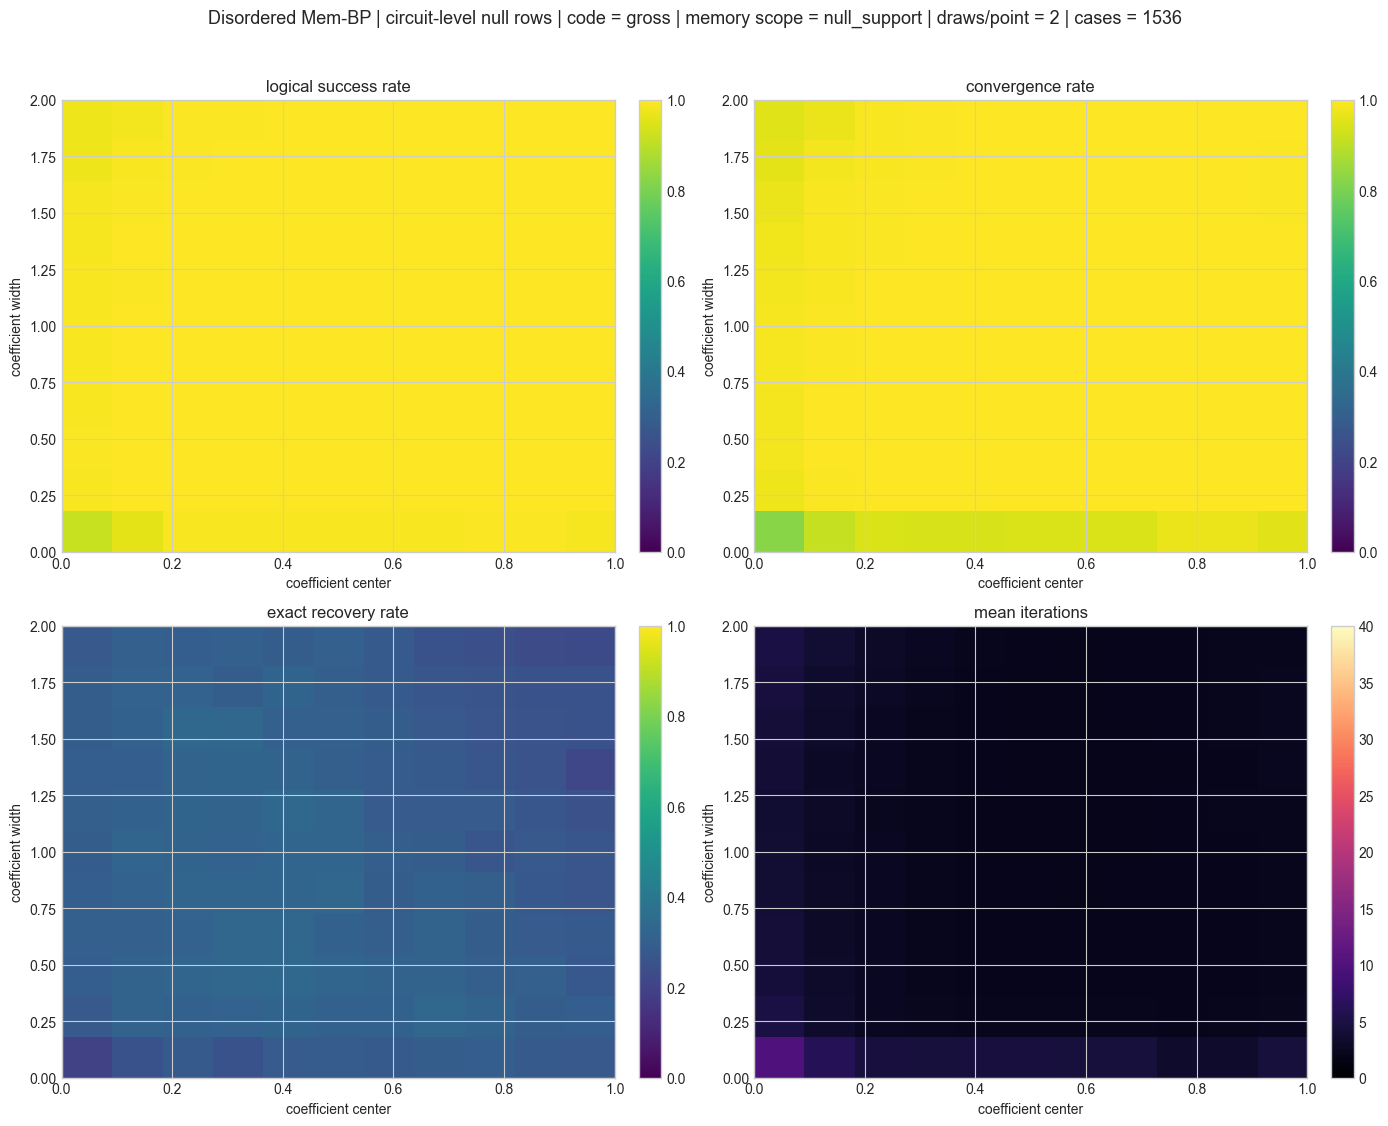

In [5]:
artifact = evaluate_parameter_heatmaps(all_cases, hz_check_matrix, lz_matrix)
grid_df = grid_table(artifact)
best_df = best_points_table(grid_df)

display(best_df)
display(grid_df.sort_values(["logical_success_rate", "convergence_rate", "mean_iterations"], ascending=[False, False, True]).head(20))
fig = plot_parameter_heatmaps(artifact)
display(fig)
plt.close(fig)